# Mission Eagle-1 - Pilote automatique LunarLander-v3

Objectif : construire un pipeline complet de reinforcement learning pour automatiser l'atterrissage du module Eagle-1 avec `LunarLander-v3`.

## Livrables

- Explorer l'environnement LunarLander.
- Entraîner un modèle PPO de référence.
- Tester plusieurs hyperparamètres un par un.
- Sauvegarder le meilleur modèle.
- Générer une vidéo de démonstration.
- Alimenter l'API et le tableau de bord Streamlit avec les artefacts générés.

In [1]:
from pathlib import Path
import time

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

from projet_11.settings import (
    ARTIFACTS_DIR,
    ENV_ID,
    LOGS_DIR,
    MODEL_PATH,
    RESULTS_PATH,
    SEED,
    VIDEO_PATH,
    ensure_artifacts_dir,
)
from projet_11.video import record_episode_video

sns.set_theme(style="whitegrid", context="notebook")
ensure_artifacts_dir()

# Garder True pour verifier rapidement tout le pipeline.
# Passer a False pour lancer les entrainements longs visant le score mission > 200.
SMOKE_TEST = False

print("Mode smoke test :", SMOKE_TEST)
print("Artefacts :", ARTIFACTS_DIR)

Mode smoke test : False
Artefacts : /home/nhkp/Documents/OpenClassroom/Projet_11/artifacts/mission


## 1. Exploration de l'environnement

`LunarLander-v3` fournit 8 observations continues et 4 actions discretes. PPO est utilise ici pour sa robustesse et parce qu'il est simple a comparer via Stable-Baselines3.

In [2]:
env = gym.make(ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Action meanings: 0=no-op, 1=left engine, 2=main engine, 3=right engine")

observation, info = env.reset(seed=SEED)
print("Initial observation:", observation)
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Action meanings: 0=no-op, 1=left engine, 2=main engine, 3=right engine
Initial observation: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]


## 2. Fonctions d'entrainement et d'evaluation

Chaque experience modifie un seul hyperparametre par rapport a la reference. Les resultats sont sauvegardes dans `artifacts/mission/results.csv`.

In [3]:
def make_monitored_env():
    env = Monitor(gym.make(ENV_ID))
    env.reset(seed=SEED)
    return env


def train_and_evaluate_experiment(name, total_timesteps, eval_episodes, **ppo_kwargs):
    env = make_monitored_env()
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=SEED,
        tensorboard_log=str(LOGS_DIR),
        **ppo_kwargs,
    )

    started_at = time.time()
    model.learn(total_timesteps=total_timesteps, tb_log_name=name)
    training_seconds = time.time() - started_at

    mean_reward, std_reward = evaluate_policy(
        model,
        env,
        n_eval_episodes=eval_episodes,
        deterministic=True,
    )

    candidate_path = ARTIFACTS_DIR / f"{name}.zip"
    model.save(candidate_path)
    env.close()

    return {
        "experiment": name,
        "total_timesteps": total_timesteps,
        "eval_episodes": eval_episodes,
        "mean_reward": float(mean_reward),
        "std_reward": float(std_reward),
        "training_seconds": round(training_seconds, 2),
        "model_path": str(candidate_path),
        "params": ppo_kwargs,
    }

## 3. Plan d'experiences

Le mode smoke-test lance des mini-entrainements pour valider le code. Pour la mission finale, passer `SMOKE_TEST = False` et relancer le notebook.

In [4]:
if SMOKE_TEST:
    experiments = [
        {"name": "baseline_smoke", "total_timesteps": 1_000, "eval_episodes": 5, "params": {}},
        {"name": "learning_rate_smoke", "total_timesteps": 1_000, "eval_episodes": 5, "params": {"learning_rate": 1e-4}},
    ]
else:
    experiments = [
        {"name": "baseline", "total_timesteps": 250_000, "eval_episodes": 50, "params": {}},
        {"name": "learning_rate_1e_4", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"learning_rate": 1e-4}},
        {"name": "gamma_0995", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"gamma": 0.995}},
        {"name": "n_steps_2048", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"n_steps": 2048}},
        {"name": "batch_size_128", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"batch_size": 128}},
        {"name": "gae_lambda_098", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"gae_lambda": 0.98}},
        {"name": "clip_range_01", "total_timesteps": 350_000, "eval_episodes": 50, "params": {"clip_range": 0.1}},
    ]

experiments

[{'name': 'baseline',
  'total_timesteps': 250000,
  'eval_episodes': 50,
  'params': {}},
 {'name': 'learning_rate_1e_4',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'learning_rate': 0.0001}},
 {'name': 'gamma_0995',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'gamma': 0.995}},
 {'name': 'n_steps_2048',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'n_steps': 2048}},
 {'name': 'batch_size_128',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'batch_size': 128}},
 {'name': 'gae_lambda_098',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'gae_lambda': 0.98}},
 {'name': 'clip_range_01',
  'total_timesteps': 350000,
  'eval_episodes': 50,
  'params': {'clip_range': 0.1}}]

In [5]:
results = []

for experiment in experiments:
    print(f"Training {experiment['name']}...")
    result = train_and_evaluate_experiment(
        experiment["name"],
        experiment["total_timesteps"],
        experiment["eval_episodes"],
        **experiment["params"],
    )
    results.append(result)
    print(f"{result['name'] if 'name' in result else result['experiment']} -> {result['mean_reward']:.2f} +/- {result['std_reward']:.2f}")

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_PATH, index=False)
results_df

Training baseline...
baseline -> 51.95 +/- 124.30
Training learning_rate_1e_4...
learning_rate_1e_4 -> 6.46 +/- 101.93
Training gamma_0995...
gamma_0995 -> 232.54 +/- 52.13
Training n_steps_2048...
n_steps_2048 -> 2.41 +/- 144.17
Training batch_size_128...
batch_size_128 -> 141.13 +/- 113.35
Training gae_lambda_098...
gae_lambda_098 -> 248.54 +/- 42.26
Training clip_range_01...
clip_range_01 -> 84.61 +/- 124.25


,experiment,total_timesteps,eval_episodes,mean_reward,std_reward,training_seconds,model_path,params
0,baseline,250000,50,51.948916,124.299245,332.52,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{}
1,learning_rate_1e_4,350000,50,6.458318,101.928718,425.67,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'learning_rate': 0.0001}
2,gamma_0995,350000,50,232.544762,52.127576,407.21,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'gamma': 0.995}
3,n_steps_2048,350000,50,2.409520,144.166941,421.88,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'n_steps': 2048}
4,batch_size_128,350000,50,141.132816,113.347687,315.78,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'batch_size': 128}
5,gae_lambda_098,350000,50,248.538008,42.261070,418.94,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'gae_lambda': 0.98}
6,clip_range_01,350000,50,84.610866,124.246404,428.70,/home/nhkp/Documents/OpenClassroom/Projet_11/a...,{'clip_range': 0.1}


## 4. Selection du meilleur modele

La mission demande une moyenne superieure a 200 sur 100 episodes. En smoke-test, on sauvegarde le meilleur candidat pour pouvoir tester l'API, la video et le dashboard.

In [6]:
best_row = results_df.sort_values("mean_reward", ascending=False).iloc[0]
best_candidate_path = Path(best_row["model_path"])

best_model = PPO.load(best_candidate_path)
best_model.save(MODEL_PATH)

final_eval_episodes = 10 if SMOKE_TEST else 100
final_env = make_monitored_env()
final_mean_reward, final_std_reward = evaluate_policy(
    best_model,
    final_env,
    n_eval_episodes=final_eval_episodes,
    deterministic=True,
)
final_env.close()

print("Best candidate:", best_row["experiment"])
print(f"Final evaluation over {final_eval_episodes} episodes: {final_mean_reward:.2f} +/- {final_std_reward:.2f}")
print("Saved model:", MODEL_PATH)

if not SMOKE_TEST and final_mean_reward <= 200:
    print("Mission target not reached yet. Add longer training or continue tuning from the best experiment.")

Best candidate: gae_lambda_098
Final evaluation over 100 episodes: 232.63 +/- 65.31
Saved model: /home/nhkp/Documents/OpenClassroom/Projet_11/artifacts/mission/best_lunarlander_ppo.zip


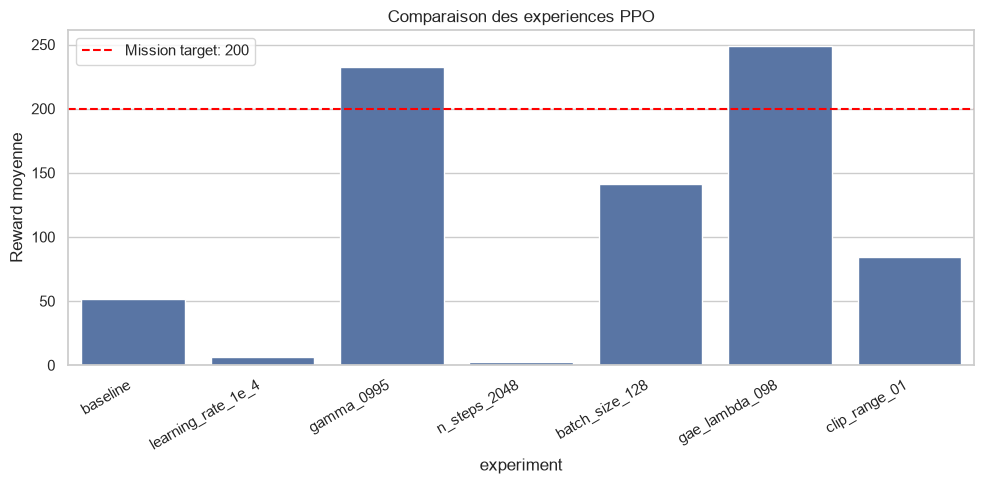

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="experiment", y="mean_reward")
plt.axhline(200, color="red", linestyle="--", label="Mission target: 200")
plt.xticks(rotation=30, ha="right")
plt.title("Comparaison des experiences PPO")
plt.ylabel("Reward moyenne")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Generation de la video

La video exportee sert de livrable visuel et peut etre reutilisee dans l'application Streamlit.

In [8]:
video_path = record_episode_video(MODEL_PATH, VIDEO_PATH, min_seconds=20, max_seconds=30)
print("Video written to:", video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video written to: /home/nhkp/Documents/OpenClassroom/Projet_11/artifacts/mission/eagle1_landing.mp4


## 6. Utilisation API et dashboard

L'API charge `artifacts/mission/best_lunarlander_ppo.zip` et expose un endpoint `/play`.

```bash
uvicorn projet_11.api:app --reload
```

Le dashboard Streamlit affiche les resultats et la video.

```bash
streamlit run src/projet_11/app.py
```